**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


## Logistic regressor

### Data Preparation

In [2]:
from collections import Counter
from collections import defaultdict

In [60]:
df_original = pd.read_csv("dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv")
df = pd.read_csv("cmi_internet_copie_2.csv")
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,PCIAT-PCIAT_20,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,16.877316,46.0,50.8,26.000,...,4.0,0,56.00,73.80,0,3.0,6.5,20.6250,2.010,448.0
1,2,9.0,0.0,1,58.95,0,14.035590,48.0,46.0,22.000,...,0.0,0,46.00,64.00,2,0.0,11.0,20.6250,2.010,448.0
2,2,10.0,1.0,0,71.00,0,16.648696,56.5,75.6,25.675,...,1.0,0,38.00,54.00,2,2.0,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,18.292347,56.0,81.6,26.000,...,1.0,2,31.00,45.00,3,0.0,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,0,17.937682,55.0,77.0,26.000,...,0.9,0,38.45,53.95,1,1.0,9.0,20.9675,1.040,448.0


In [61]:
df['Basic_Demos-Sex'] = df_original['Basic_Demos-Sex']

# Verifica rapida
print(df['Basic_Demos-Sex'].value_counts())

Basic_Demos-Sex
0    5056
1    3404
Name: count, dtype: int64


In [62]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (8460, 83)
Shape y: (8460,)


### Data Partitioning

In [63]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [45]:
from sklearn.preprocessing import StandardScaler

In [65]:
scl = StandardScaler()
X_train_scaled = scl.fit_transform(X_train)
X_test_scaled = scl.transform(X_test)

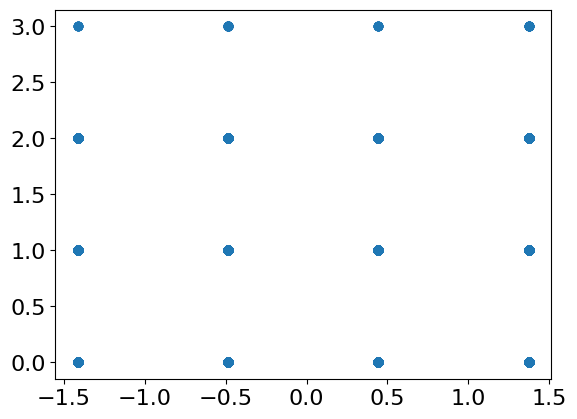

In [9]:
plt.scatter(X_train.T[0], y_train)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [17]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Definizione della Pipeline
# L'ordine è cruciale: SMOTE -> SelectKBest -> Classifier
pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectKBest(score_func=f_classif)), # ANOVA
    ('log_reg', LogisticRegression(max_iter=2000, random_state=42))
])

# 'feature_selection__k' per ottimizzare il numero di feature da tenere
param_grid = {
    'feature_selection__k': [5, 10, 15, 'all'], 
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2'],
    'log_reg__solver': ['saga']
}

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

print("Training with SMOTE and SelectKBest integrated into cross-validation...")
grid_search.fit(X_train_scaled, y_train)

# Risultati
best_model = grid_search.best_estimator_

print("\nOptimization results:")
print("Best hyperparameters found:", grid_search.best_params_)

# Valutazione
y_pred = best_model.predict(X_test_scaled)

print("\nEvaluation on test set:")
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-score (per class): {f1_score(y_test, y_pred, average=None)}')
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Training with SMOTE and SelectKBest integrated into cross-validation...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Optimization results:
Best hyperparameters found: {'feature_selection__k': 'all', 'log_reg__C': 0.01, 'log_reg__penalty': 'l1', 'log_reg__solver': 'saga'}

Evaluation on test set:
Accuracy: 0.5331
F1-score (per class): [0.70894526 0.31914894 0.35167785 0.05063291]

Full Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.61      0.71      1749
         1.0       0.33      0.31      0.32       482
         2.0       0.28      0.47      0.35       280
         3.0       0.03      0.37      0.05        27

    accuracy                           0.53      2538
   macro avg       0.37      0.44      0.36      2538
weighted avg       0.68      0.53      0.59      2538



In [66]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectKBest(score_func=f_classif)), # ANOVA
    ('log_reg', LogisticRegression(max_iter=2000, random_state=42))
])

param_dist = {
    'feature_selection__k': [5, 10, 15, 'all'], 
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2'],
    'log_reg__solver': ['saga']
}

random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist, 
    n_iter=5,
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    random_state=42
)

print("Training with SMOTE integrated into cross-validation (RandomizedSearch)...")
random_search.fit(X_train_scaled, y_train)

best_model = random_search.best_estimator_

print("\n Optimization results:")
print("Best hyperparameters found:", random_search.best_params_)

y_pred = best_model.predict(X_test_scaled)

print("\n Evaluation on test set:")
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Training with SMOTE integrated into cross-validation (RandomizedSearch)...


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



 Optimization results:
Best hyperparameters found: {'log_reg__solver': 'saga', 'log_reg__penalty': 'l1', 'log_reg__C': 10, 'feature_selection__k': 15}

 Evaluation on test set:
Accuracy 0.5193065405831363
F1-score [0.70165017 0.32208923 0.37881874 0.04402516]
              precision    recall  f1-score   support

         0.0       0.83      0.61      0.70      1749
         1.0       0.34      0.31      0.32       482
         2.0       0.44      0.33      0.38       280
         3.0       0.02      0.52      0.04        27

    accuracy                           0.52      2538
   macro avg       0.41      0.44      0.36      2538
weighted avg       0.69      0.52      0.59      2538



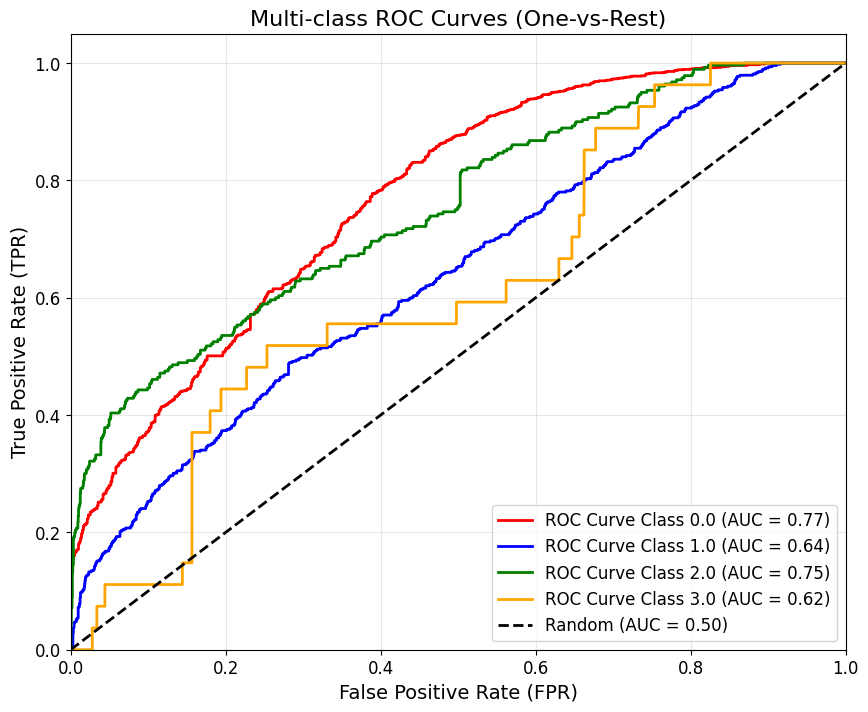

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Binarize the labels for the multi-class problem (One-vs-Rest)
classes = [0.0, 1.0, 2.0, 3.0]
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# 2. Retrieve predicted probabilities from the best model
# (best_model corresponds to the model from GridSearchCV or RandomizedSearchCV)
y_score = best_model.predict_proba(X_test_scaled)

# 3. Calculate False Positive Rates (fpr) and True Positive Rates (tpr) for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC curves
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC Curve Class {classes[i]} (AUC = {roc_auc[i]:0.2f})')

# Baseline (random)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('Multi-class ROC Curves (One-vs-Rest)', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid(alpha=0.3)
plt.show()

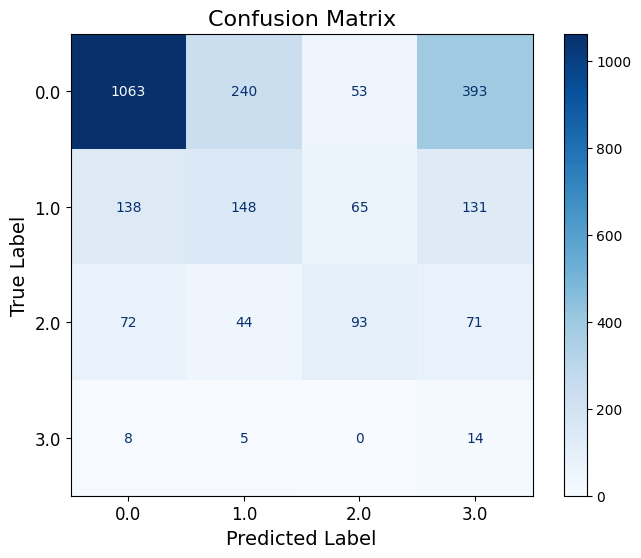

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid(False)
plt.show()

It proves that while SMOTE forced the model to pay attention to classes 2 and 3, Logistic Regression is too rigid (linear) to handle the complexity of this specific dataset.

In [24]:

intercept = best_model.named_steps['log_reg'].intercept_

print("Intercept :")
print(intercept)

Intercept :
[ 0.1964702   0.12791365 -0.14758306 -0.1768008 ]


In [25]:
coefficients = best_model.named_steps['log_reg'].coef_

print("Coefficients :")
print(coefficients)

Coefficients :
[[-3.46595400e-01 -3.47066736e-02 -4.25687032e-01  4.90387141e-02
  -3.61309122e-01  2.29593841e-02 -6.77756662e-02 -1.89904577e-01
  -2.44656209e-01 -1.28197277e-01 -4.09767888e-01 -5.93977835e-02
   2.91928899e-01  7.14972774e-06 -2.97601718e-01]
 [-1.58268818e-01  5.46548010e-02 -2.02944187e-06  2.87203200e-01
   1.46066731e-01 -9.60503649e-02  4.51958649e-03 -9.77339079e-02
   7.65709950e-02 -1.46059324e-02 -5.09112379e-03  3.09631210e-03
   9.33863672e-02 -8.53615593e-02 -1.12401740e-01]
 [ 1.42802758e-01  3.44053921e-02  7.54738310e-02 -3.39172692e-07
  -6.13128461e-05 -7.46895438e-02  5.61680791e-02  4.69418725e-02
  -2.99516430e-05  5.52652280e-06  2.30958449e-01 -9.79903265e-04
  -4.81196008e-02  2.29717873e-01  9.79499008e-02]
 [ 3.62091793e-01 -5.47218748e-02  1.52546420e-02 -7.73451566e-01
   1.06642241e-01  1.47983360e-01 -3.40902809e-04  2.41373312e-01
   1.05723514e-01  1.92467510e-01  1.78767483e-01  5.13541917e-02
  -3.37962382e-01 -1.01918369e-01  3.121

In [26]:
from scipy.special import expit

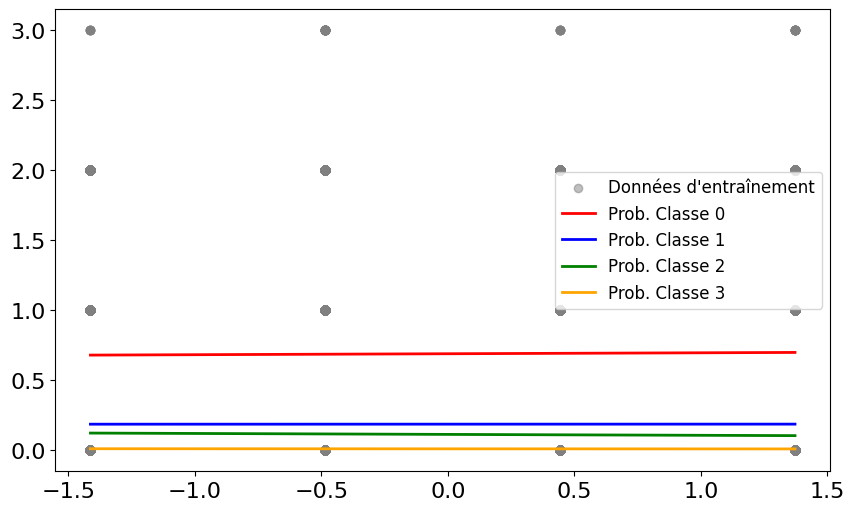

In [28]:
# 1. On isole la colonne spécifique (feature 0) pour l'entraînement et le test
X_train_1D = X_train_scaled[:, 0].reshape(-1, 1) 
X_test_1D = X_test_scaled[:, 0].reshape(-1, 1)

# 2. On entraîne un NOUVEAU modèle temporaire uniquement sur cette colonne
clf_1D = LogisticRegression(max_iter=2000, random_state=42)
clf_1D.fit(X_train_1D, y_train)

# 3. Préparation des données pour l'axe X (triées pour tracer des lignes continues)
X_plot = np.sort(X_test_1D, axis=0)

# 4. Calcul des probabilités avec ce modèle 1D (qui s'attend bien à 1 seule colonne)
probas = clf_1D.predict_proba(X_plot)

# 5. Création du graphique
plt.figure(figsize=(10, 6))
plt.scatter(X_train_1D, y_train, color='grey', alpha=0.5, label="Données d'entraînement")

colors = ['red', 'blue', 'green', 'orange']
for i in range(probas.shape[1]):
    plt.plot(X_plot, probas[:, i], color=colors[i], linewidth=2, label=f'Prob. Classe {i}')

plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=12)
plt.show()

It clearly demonstrates that features cannot separate the classes using simple linear rules.

### New target variable data preparation 

**Basic_Demos-Sex**

In [47]:
df['sii']=df_original.loc[df.index, 'sii']
df.head()

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,sii
0,0,5.0,0,3,51.00,0,16.877316,46.0,50.8,26.000,...,0,56.00,73.80,0,3.0,6.5,20.6250,2.010,448.0,2.0
1,2,9.0,0,1,58.95,0,14.035590,48.0,46.0,22.000,...,0,46.00,64.00,2,0.0,11.0,20.6250,2.010,448.0,0.0
2,2,10.0,1,0,71.00,0,16.648696,56.5,75.6,25.675,...,0,38.00,54.00,2,2.0,10.0,12.4500,2.009,453.0,0.0
3,3,9.0,0,0,71.00,2,18.292347,56.0,81.6,26.000,...,2,31.00,45.00,3,0.0,7.0,20.6250,2.010,577.0,1.0
4,1,18.0,1,2,65.00,0,17.937682,55.0,77.0,26.000,...,0,38.45,53.95,1,1.0,9.0,20.9675,1.040,448.0,0.0


In [48]:
df_log_reg = df.copy()

In [49]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [50]:
X = df.values
y = np.array(df_log_reg['Basic_Demos-Sex'])

In [51]:
ctr = Counter(y)
ctr

Counter({0: 5056, 1: 3404})

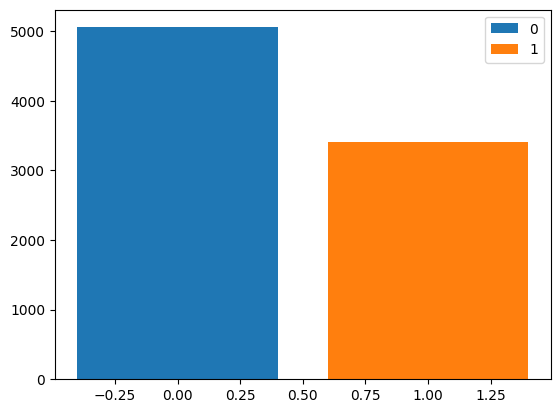

In [52]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange'])
plt.legend()
plt.show()

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [56]:
scl = StandardScaler()
X_train_scaled = scl.fit_transform(X_train)
X_test_scaled = scl.transform(X_test)

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Definizione della Pipeline
# L'ordine è cruciale: SMOTE -> SelectKBest -> Classifier
pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectKBest(score_func=f_classif)), # ANOVA
    ('log_reg', LogisticRegression(max_iter=2000, random_state=42))
])

# 'feature_selection__k' per ottimizzare il numero di feature da tenere
param_grid = {
    'feature_selection__k': [5, 10, 15, 'all'], 
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2'],
    'log_reg__solver': ['saga']
}

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    verbose=1
)

print("Training with SMOTE and SelectKBest integrated into cross-validation...")
grid_search.fit(X_train_scaled, y_train)

# Risultati
best_model = grid_search.best_estimator_

print("\nOptimization results:")
print("Best hyperparameters found:", grid_search.best_params_)

# Valutazione
y_pred = best_model.predict(X_test_scaled)

print("\nEvaluation on test set:")
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-score (per class): {f1_score(y_test, y_pred, average=None)}')
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

Training with ADASYN integrated into cross-validation...

 Optimization results:
Best hyperparameters found: {'log_reg__C': 1, 'log_reg__penalty': 'l2', 'log_reg__solver': 'saga'}

 Evaluation on test set:
Accuracy 0.5977519068647129
F1-score [0.60015962 0.59531502]
              precision    recall  f1-score   support

         0.0       0.74      0.51      0.60      1484
         1.0       0.50      0.73      0.60      1007

    accuracy                           0.60      2491
   macro avg       0.62      0.62      0.60      2491
weighted avg       0.64      0.60      0.60      2491



In [57]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectKBest(score_func=f_classif)), # ANOVA
    ('log_reg', LogisticRegression(max_iter=2000, random_state=42))
])

param_dist = {
    'feature_selection__k': [5, 10, 15, 'all'], 
    'log_reg__C': [0.01, 0.1, 1, 10, 100],
    'log_reg__penalty': ['l1', 'l2'],
    'log_reg__solver': ['saga']
}

random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist, 
    n_iter=5,
    cv=5, 
    scoring='f1_macro', 
    n_jobs=-1,
    random_state=42
)

print("Training with SMOTE integrated into cross-validation (RandomizedSearch)...")
random_search.fit(X_train_scaled, y_train)

best_model = random_search.best_estimator_

print("\n Optimization results:")
print("Best hyperparameters found:", random_search.best_params_)

y_pred = best_model.predict(X_test_scaled)

print("\n Evaluation on test set:")
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Training with SMOTE integrated into cross-validation (RandomizedSearch)...


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



 Optimization results:
Best hyperparameters found: {'log_reg__solver': 'saga', 'log_reg__penalty': 'l1', 'log_reg__C': 10, 'feature_selection__k': 15}

 Evaluation on test set:
Accuracy 0.6008668242710796
F1-score [0.74138371 0.12597066]
              precision    recall  f1-score   support

           0       0.60      0.96      0.74      1516
           1       0.53      0.07      0.13      1022

    accuracy                           0.60      2538
   macro avg       0.57      0.51      0.43      2538
weighted avg       0.58      0.60      0.49      2538



c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


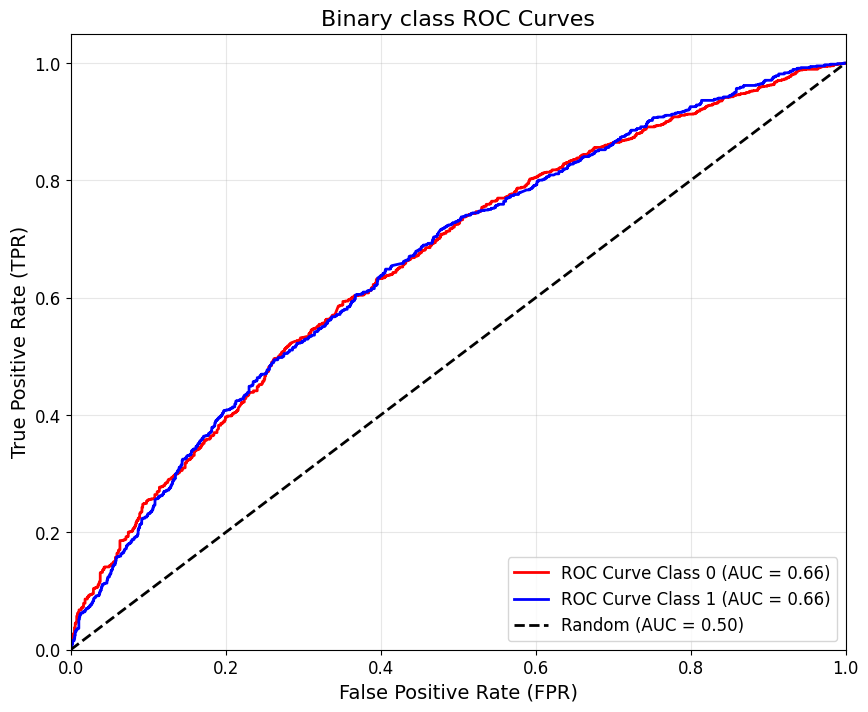

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Binarize the labels
classes = [0, 1]
y_test_bin = label_binarize(y_test, classes=classes)

# FIX: Because label_binarize returns a 1D column for 2 classes, 
# we stack the inverse to explicitly create a 2D array [Class 0, Class 1]
y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))
n_classes = 2

# 2. Retrieve predicted probabilities from the best model
y_score = best_model.predict_proba(X_test)

# 3. Calculate False Positive Rates (fpr) and True Positive Rates (tpr) for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot the ROC curves
plt.figure(figsize=(10, 8))
colors = ['red', 'blue']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC Curve Class {classes[i]} (AUC = {roc_auc[i]:0.2f})')

# Baseline (random)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title('Binary class ROC Curves', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid(alpha=0.3)
plt.show()

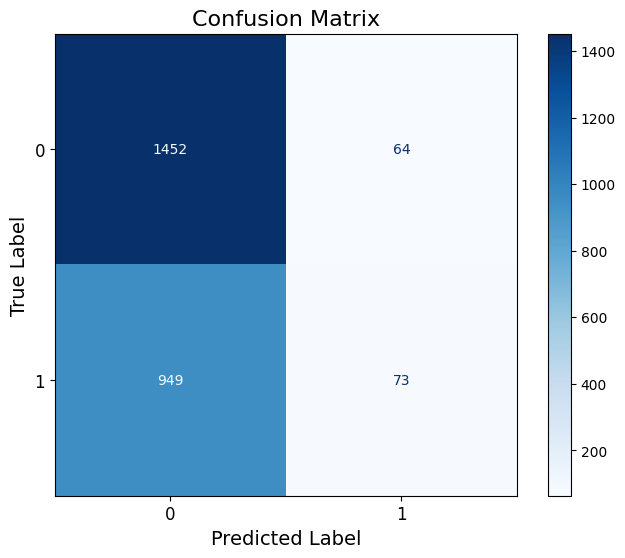

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.grid(False)
plt.show()